In [1]:
import os
from argparse import ArgumentParser

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from neuralut.nn import (
    generate_truth_tables,
    lut_inference,
    module_list_to_verilog_module,
)

from train import configs, model_config, test
from models import MnistNeqModel
from neuralut.synthesis import synthesize_and_get_resource_counts

cuda_device = 2
config = configs["hdr-5l-0.1"]
torch.cuda.set_device(cuda_device)

In [2]:
# Fetch the test set
dataset = {}
dataset["test"] = datasets.MNIST(
    "mnist_data",
    download=False,
    train=False,
    transform=transforms.Compose(
        [
            transforms.ToTensor(),  # first, convert image to PyTorch tensor
            transforms.Normalize((0.1307,), (0.3081,)),  # normalize inputs
        ]
    ),
)
test_loader = DataLoader(
    dataset["test"], batch_size=config["batch_size"], shuffle=False
)

In [3]:
imask = torch.load("./test_demo/imask.pth", map_location="cuda:{}".format(cuda_device))

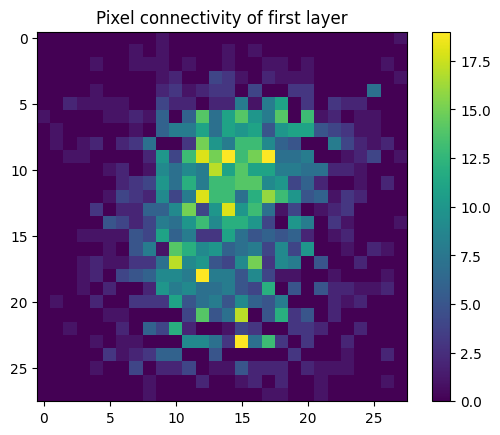

In [4]:
# Visualize the first layer sparsity pattern
imask_input = imask[:2160]

import matplotlib.pyplot as plt
import numpy as np

# Initialize an empty grid for a 28x28 image
grid = np.zeros((28, 28))

# Populate the grid with values from `imask`
# Normalize pixel indexes to 2D coordinates
for i in range(imask_input.size(0)):
    pixel_index = imask_input[i, 0].item()
    row = pixel_index // 28
    col = pixel_index % 28
    grid[row, col] += 1

# Plotting
plt.imshow(grid, cmap="viridis")
plt.colorbar()
plt.title("Pixel connectivity of first layer")
plt.show()

In [5]:
model_cfg = {}
for k in model_config.keys():
    model_cfg[k] = config[k]
model_cfg["input_length"] = 784
model_cfg["output_length"] = 10
model_cfg["imask"] = torch.load("./test_demo/imask.pth", map_location="cuda:{}".format(cuda_device))
model_cfg['dense_forward'] = False
model_cfg["cuda"] = True

In [6]:
model = MnistNeqModel(model_cfg)
model.cuda()

Creating input layer
Creating support layer
Creating hidden layer
Creating support layer
Creating support layer
Creating output layer


MnistNeqModel(
  (module_list): ModuleList(
    (0): SparseLinearNeq(
      (input_quant): QuantBrevitasActivation(
        (brevitas_module): QuantHardTanh(
          (input_quant): ActQuantProxyFromInjector(
            (_zero_hw_sentinel): StatelessBuffer()
          )
          (act_quant): ActQuantProxyFromInjector(
            (_zero_hw_sentinel): StatelessBuffer()
            (fused_activation_quant_proxy): FusedActivationQuantProxy(
              (activation_impl): Identity()
              (tensor_quant): RescalingIntQuant(
                (int_quant): IntQuant(
                  (float_to_int_impl): RoundSte()
                  (tensor_clamp_impl): TensorClamp()
                  (delay_wrapper): DelayWrapper(
                    (delay_impl): _NoDelay()
                  )
                )
                (scaling_impl): ParameterScaling(
                  (restrict_clamp_scaling): _RestrictClampValue(
                    (clamp_min_ste): Identity()
                    (rest

In [7]:
checkpoint = torch.load("./test_demo/best_accuracy.pth", map_location="cuda:{}".format(cuda_device))
model.load_state_dict(checkpoint["model_dict"])

<All keys matched successfully>

In [8]:
# Test the PyTorch model
print("Running inference on baseline model...")
baseline_accuracy = test(model, test_loader, cuda=True)
print("Baseline accuracy: %f" % (baseline_accuracy))

Running inference on baseline model...


/home/ma11418/miniconda3/envs/new_brevitas/lib/python3.8/site-packages/torch/_tensor.py:1419: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at /opt/conda/conda-bld/pytorch_1712608843393/work/c10/core/TensorImpl.h:1921.)
  return super().rename(names)


Baseline accuracy: 97.910000


In [9]:
# Generate the truth tables in the LUT module
print("Converting to NEQs to LUTs...")
generate_truth_tables(model, verbose=True)

Converting to NEQs to LUTs...
Calculating truth tables for module_list.0
Truth tables generated for 2160 neurons
Calculating truth tables for module_list.1
Truth tables generated for 360 neurons
Calculating truth tables for module_list.2
Truth tables generated for 2160 neurons
Calculating truth tables for module_list.3
Truth tables generated for 360 neurons
Calculating truth tables for module_list.4
Truth tables generated for 60 neurons
Calculating truth tables for module_list.5
Truth tables generated for 10 neurons


In [10]:
# Test the LUT-based model
print("Running inference on LUT-based model...")
lut_inference(model)
lut_accuracy = test(model, test_loader, cuda=True)
print("LUT-Based Model accuracy: %f" % (lut_accuracy))
modelSave = {"model_dict": model.state_dict(), "test_accuracy": lut_accuracy}
torch.save(modelSave, "./test_demo/verilog/" + "/lut_based_model.pth")


Running inference on LUT-based model...
LUT-Based Model accuracy: 97.870000


In [11]:
print("Generating verilog in %s..." % ("./test_demo/verilog/"))
module_list_to_verilog_module(
    model.module_list,
    "neuralut",
    "./test_demo/verilog/",
    add_registers=True,
)
print("Top level entity stored at: %s/neuralut.v ..." % ("./test_demo/verilog/"))


Generating verilog in ./test_demo/verilog/...
Top level entity stored at: ./test_demo/verilog//neuralut.v ...


In [12]:
import os

os.environ["OHMYXILINX"] = "/home/ma11418/NeuraLUT_Private/NeuraLUT_Private/oh-my-xilinx"

In [13]:
print("Running out-of-context synthesis")
ret = synthesize_and_get_resource_counts("./test_demo/verilog/", "neuralut", fpga_part='xcvu9p-flgb2104-2-i', clk_period_ns='1.1', post_synthesis=1)
print("Max f: " + str(ret))

Running out-of-context synthesis


/home/ma11418/NeuraLUT_Private/NeuraLUT_Private/oh-my-xilinx/vivadoprojgen.sh:31: no matches found: ../*.vhd
/home/ma11418/NeuraLUT_Private/NeuraLUT_Private/oh-my-xilinx/vivadoprojgen.sh:33: no matches found: ../*.h
/home/ma11418/NeuraLUT_Private/NeuraLUT_Private/oh-my-xilinx/vivadoprojgen.sh:34: no matches found: ../*.xdc
/home/ma11418/NeuraLUT_Private/NeuraLUT_Private/oh-my-xilinx/vivadoprojgen.sh:35: no matches found: ../*.vh
cat: neuralut.xdc: input file is output file


['LUT', '5056']
['FF', '5647']
['DSP', '0']
['BRAM', '0']
['WNS', '-0.007']
['']
Max f: {'vivado_proj_folder': './test_demo/verilog//results_neuralut', 'LUT': 5056.0, 'FF': 5647.0, 'DSP': 0.0, 'BRAM': 0.0, 'WNS': -0.007, '': 0, 'fmax_mhz': 903.342366757001}
